# Chronos-2 Quality Net — Context Length Comparison (실측치 데이터)

`Cement_code/chronos_quality/results_context_comparison.ipynb`의 재현판. 데이터만 **운전&품질데이터_실측치.xlsx**(`data/processed/quality_timeseries.csv`)로 바꾸고, **11개 context_length** (24 / 73 / 128 / 168 / 256 / 384 / 512 / 768 / 1024 / 1280 / 1536) × **blaine / residue** × **zero-shot / LoRA / Full fine-tune** 전부를 구 folder와 동일한 하이퍼파라미터로 학습·평가:

- `prediction_length` 4 (학습) / 1 (평가) · `num_steps` 1000 · `batch_size` 64 · backtest `stride` 4
- Full `lr` 1e-6 · LoRA `lr` 1e-5 · zero-shot = `amazon/chronos-2` 그대로 backtest

집계는 **정규화 skill-score** (`eval/metrics_utils.normalized_skill_score`): 호기(2CM/3CM/4CM)별 `model MAE / naive MAE` 비율을 동등 평균. **1.0 미만이면 naive baseline보다 낫다**는 뜻.

GPU 안 씀 — 저장된 `eval/backtest_*.csv` / `checkpoints/*/loss_history.csv`만 읽음.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score
from eval.loss_history import overfit_summary

CONTEXTS = [24, 73, 128, 168, 256, 384, 512, 768, 1024, 1280, 1536]
TARGETS = cfg.TARGET_COLS            # ['blaine', 'residue']
METHODS = {'zero-shot': 'zeroshot', 'LoRA': 'lora', 'Full fine-tuning': 'full'}
COLOR = {'blaine': 'tab:blue', 'residue': 'tab:orange'}
MCOLOR = {'zero-shot': 'tab:blue', 'LoRA': 'tab:orange', 'Full fine-tuning': 'tab:green'}


## 1. 결과 로딩 (11 ctx × 2 target × 3 method + loss history)

In [2]:
raw = {t: {m: {} for m in METHODS} for t in TARGETS}
loss = {t: {} for t in TARGETS}
missing = []
for t in TARGETS:
    for label, suf in METHODS.items():
        for ctx in CONTEXTS:
            p = ROOT / 'eval' / f'backtest_{t}_ctx{ctx}_{suf}.csv'
            if p.exists():
                raw[t][label][ctx] = pd.read_csv(p, parse_dates=['timestamp'])
            else:
                missing.append(p.name)
    for ctx in CONTEXTS:
        # Full checkpoints: checkpoints/{t}_ctx{ctx}/loss_history.csv
        lp = ROOT / 'checkpoints' / f'{t}_ctx{ctx}' / 'loss_history.csv'
        if lp.exists():
            loss[t][ctx] = pd.read_csv(lp)
print('missing backtests:', missing or 'NONE')
print('backtests loaded  :', sum(len(raw[t][m]) for t in TARGETS for m in METHODS), '/ 66')
print('Full loss curves  :', sum(len(loss[t]) for t in TARGETS), '/ 22')

def naive_metrics(t, ctx):
    df = raw[t]['Full fine-tuning'][ctx]
    return compute_metrics(df.assign(pred=df['naive_pred']), cfg.SPEC_RANGES[t])


missing backtests: NONE
backtests loaded  : 66 / 66
Full loss curves  : 22 / 22


## 2. context_length별 학습 과적합 확인 (Full fine-tuning loss curve)

파란=blaine, 주황=residue. 실선=train_loss, 점선=val_loss. 세로 점선=val_loss 최소 지점. 제목의 `Δval` = `val_loss_final − val_loss_min` (0보다 크면 과적합 신호). 구 folder와 달리 여기 loss curve는 **backtest에 쓰인 바로 그 학습 실행**의 것 (`make_loss_history_callback` 기반, `_v2` 재학습본 아님).

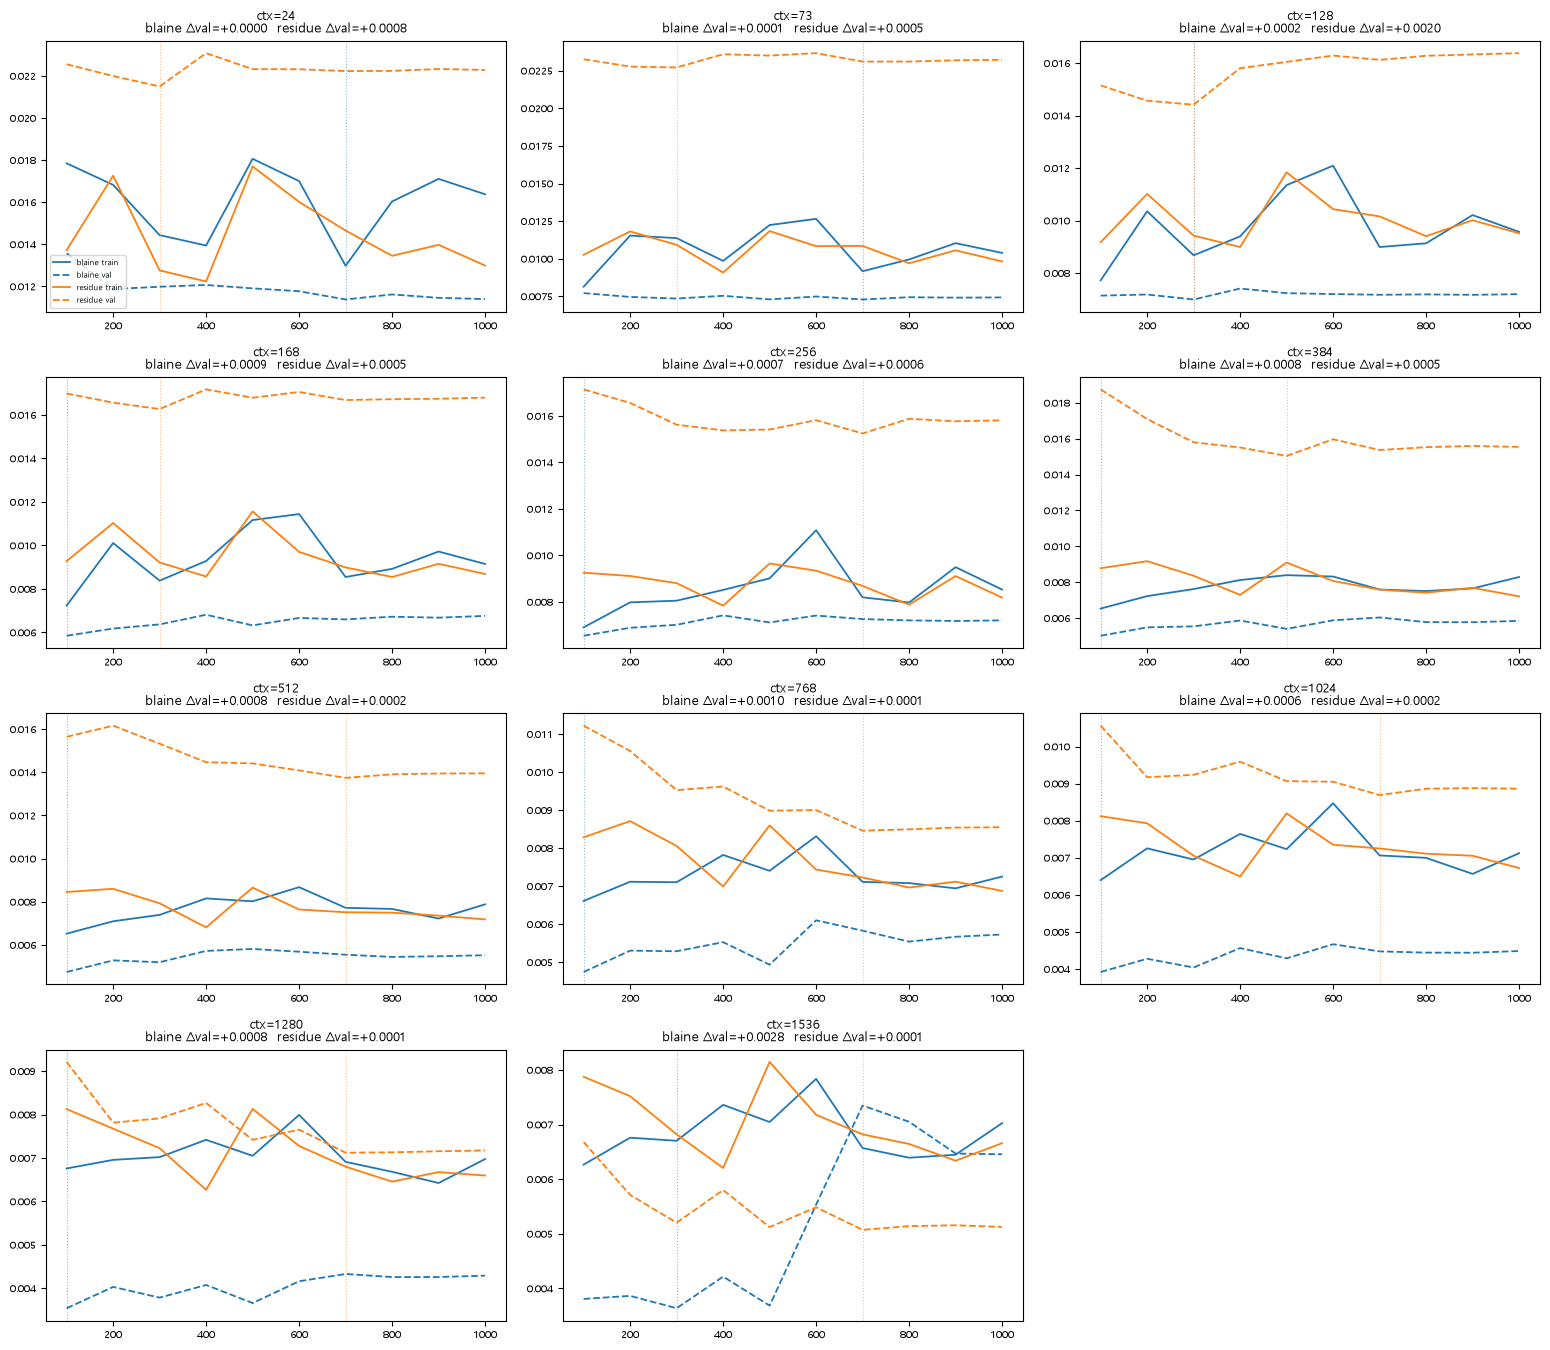

 target  ctx  val_loss_min  val_loss_final  final_minus_min
 blaine   24       0.01138         0.01140          0.00002
 blaine   73       0.00729         0.00743          0.00014
 blaine  128       0.00699         0.00720          0.00020
 blaine  168       0.00585         0.00676          0.00091
 blaine  256       0.00654         0.00720          0.00066
 blaine  384       0.00502         0.00585          0.00083
 blaine  512       0.00475         0.00552          0.00078
 blaine  768       0.00474         0.00573          0.00099
 blaine 1024       0.00392         0.00449          0.00057
 blaine 1280       0.00354         0.00429          0.00075
 blaine 1536       0.00364         0.00646          0.00282
residue   24       0.02150         0.02228          0.00078
residue   73       0.02272         0.02323          0.00051
residue  128       0.01442         0.01638          0.00196
residue  168       0.01627         0.01680          0.00053
residue  256       0.01525         0.015

In [3]:
ncols = 3
nrows = -(-len(CONTEXTS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows))
axes = axes.flatten()
ov = []
for i, ctx in enumerate(CONTEXTS):
    ax = axes[i]
    for t in TARGETS:
        df = loss[t].get(ctx)
        if df is None:
            continue
        tr = df.dropna(subset=['train_loss']); va = df.dropna(subset=['val_loss'])
        ax.plot(tr['step'], tr['train_loss'], color=COLOR[t], lw=1.3, label=f'{t} train')
        ax.plot(va['step'], va['val_loss'], color=COLOR[t], lw=1.3, ls='--', label=f'{t} val')
        s = overfit_summary(df); s.update({'target': t, 'ctx': ctx}); ov.append(s)
        if s.get('n_val_points'):
            ax.axvline(s['val_loss_min_step'], color=COLOR[t], ls=':', lw=0.8, alpha=0.5)
    gaps = '  '.join(f"{r['target']} Δval={r['final_minus_min']:+.4f}"
                     for r in ov if r['ctx'] == ctx and r.get('n_val_points'))
    ax.set_title(f'ctx={ctx}\n{gaps}', fontsize=9)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6)
for j in range(len(CONTEXTS), len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()
print(pd.DataFrame(ov).sort_values(['target', 'ctx'])[
    ['target', 'ctx', 'val_loss_min', 'val_loss_final', 'final_minus_min']].round(5).to_string(index=False))


## 3. context_length별 정규화 skill-score (Full fine-tuning)

막대 = `model MAE / naive MAE` (호기 3개 평균). **1.0(빨간 점선) 아래로 갈수록 좋음.**

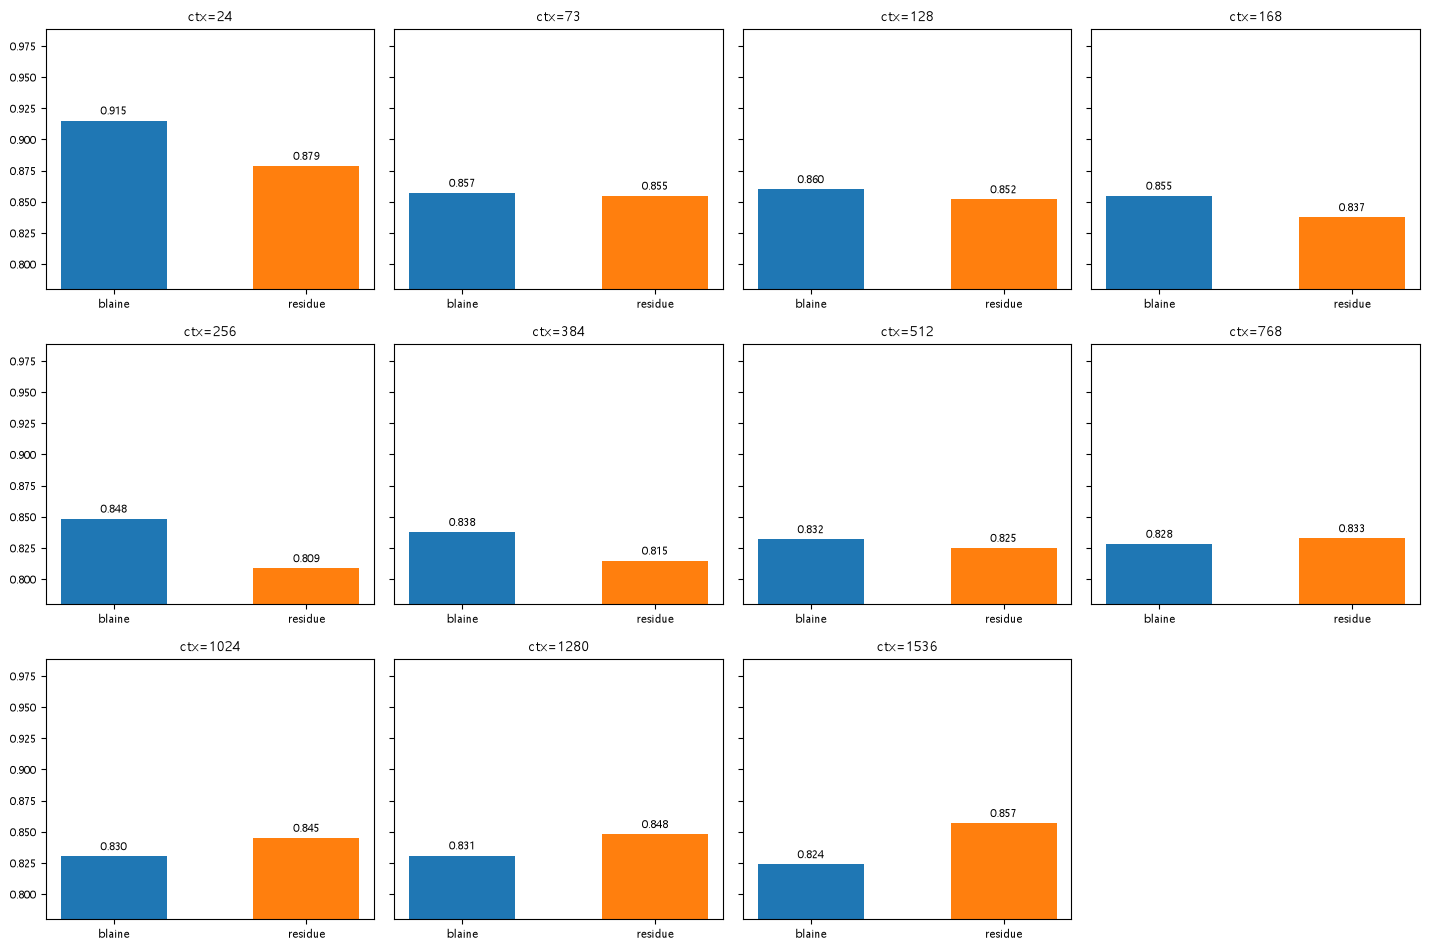

In [4]:
score = {t: {ctx: normalized_skill_score(raw[t]['Full fine-tuning'][ctx]) for ctx in CONTEXTS} for t in TARGETS}
ncols = 4
nrows = -(-len(CONTEXTS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.2 * nrows), sharey=True)
axes = axes.flatten()
ymax = max(v for t in TARGETS for v in score[t].values()) * 1.08
for i, ctx in enumerate(CONTEXTS):
    ax = axes[i]
    vals = [score[t][ctx] for t in TARGETS]
    b = ax.bar(TARGETS, vals, color=[COLOR[t] for t in TARGETS], width=0.55)
    ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.7)
    for bb, v in zip(b, vals):
        ax.text(bb.get_x() + bb.get_width() / 2, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_title(f'ctx={ctx}', fontsize=10); ax.set_ylim(0.78, ymax); ax.tick_params(labelsize=8)
for j in range(len(CONTEXTS), len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()


## 4. context_length 추세 (정규화 skill-score, 3 방식)

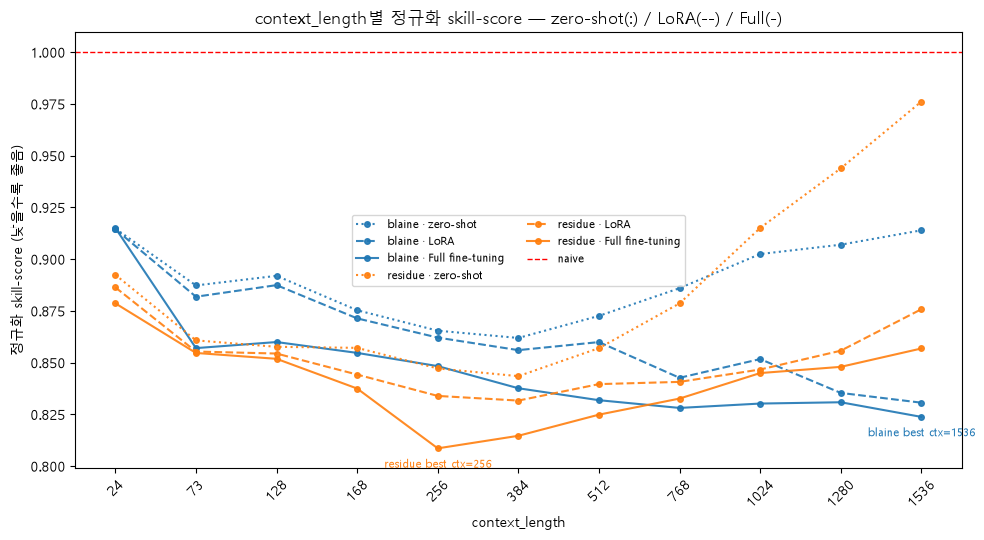

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
xs = list(range(len(CONTEXTS)))
for t in TARGETS:
    for label in METHODS:
        ys = [normalized_skill_score(raw[t][label][ctx]) for ctx in CONTEXTS]
        ls = {'zero-shot': ':', 'LoRA': '--', 'Full fine-tuning': '-'}[label]
        ax.plot(xs, ys, ls, marker='o', ms=4, color=COLOR[t], alpha=0.9,
                label=f'{t} · {label}')
        if label == 'Full fine-tuning':
            bi = int(np.argmin(ys))
            ax.annotate(f'{t} best ctx={CONTEXTS[bi]}', (bi, ys[bi]),
                        textcoords='offset points', xytext=(0, -14), ha='center', fontsize=8, color=COLOR[t])
ax.axhline(1.0, color='red', ls='--', lw=1, label='naive')
ax.set_xticks(xs); ax.set_xticklabels(CONTEXTS, rotation=45)
ax.set_xlabel('context_length'); ax.set_ylabel('정규화 skill-score (낮을수록 좋음)')
ax.set_title('context_length별 정규화 skill-score — zero-shot(:) / LoRA(--) / Full(-)')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


## 5. 순위표 (Full fine-tuning — 정규화 / macro / pooled MAE)

In [6]:
for t in TARGETS:
    rows = []
    for ctx in CONTEXTS:
        df = raw[t]['Full fine-tuning'][ctx]
        rows.append({'ctx': ctx,
                     'skill_norm': round(normalized_skill_score(df), 4),
                     'macro_MAE': round(macro_average_mae(df), 4),
                     'pooled_MAE': round(compute_metrics(df, cfg.SPEC_RANGES[t])['MAE'], 4)})
    tab = pd.DataFrame(rows).sort_values('skill_norm').reset_index(drop=True)
    print(f'=== {t} (정규화 skill-score 순) ===')
    print(tab.to_string(index=False))
    print(f'  -> 최적 context_length = {int(tab.iloc[0]["ctx"])}\n')


=== blaine (정규화 skill-score 순) ===
 ctx  skill_norm  macro_MAE  pooled_MAE
1536      0.8238    68.9180     68.9334
 768      0.8281    69.2787     69.2941
1024      0.8302    69.4569     69.4746
1280      0.8309    69.5437     69.5419
 512      0.8319    69.5736     69.6349
 384      0.8376    70.0466     70.0427
 256      0.8483    70.9490     70.9475
 168      0.8547    71.5540     71.5391
  73      0.8570    71.7200     71.7877
 128      0.8599    72.0029     72.0412
  24      0.9151    76.7517     76.8125
  -> 최적 context_length = 1536

=== residue (정규화 skill-score 순) ===
 ctx  skill_norm  macro_MAE  pooled_MAE
 256      0.8086     0.4581      0.4585
 384      0.8147     0.4618      0.4623
 512      0.8249     0.4671      0.4671
 768      0.8326     0.4714      0.4714
 168      0.8375     0.4750      0.4754
1024      0.8450     0.4786      0.4788
1280      0.8480     0.4803      0.4807
 128      0.8518     0.4837      0.4841
  73      0.8547     0.4845      0.4849
1536      0.8568  

## 6. 상세 지표 추세 (Full fine-tuning, pooled)

MAE(낮을수록) / R²(높을수록) / Spec 정확도(높을수록) / 80% 커버리지(0.80 초록선에 가까울수록). 회색 점선 = naive baseline.

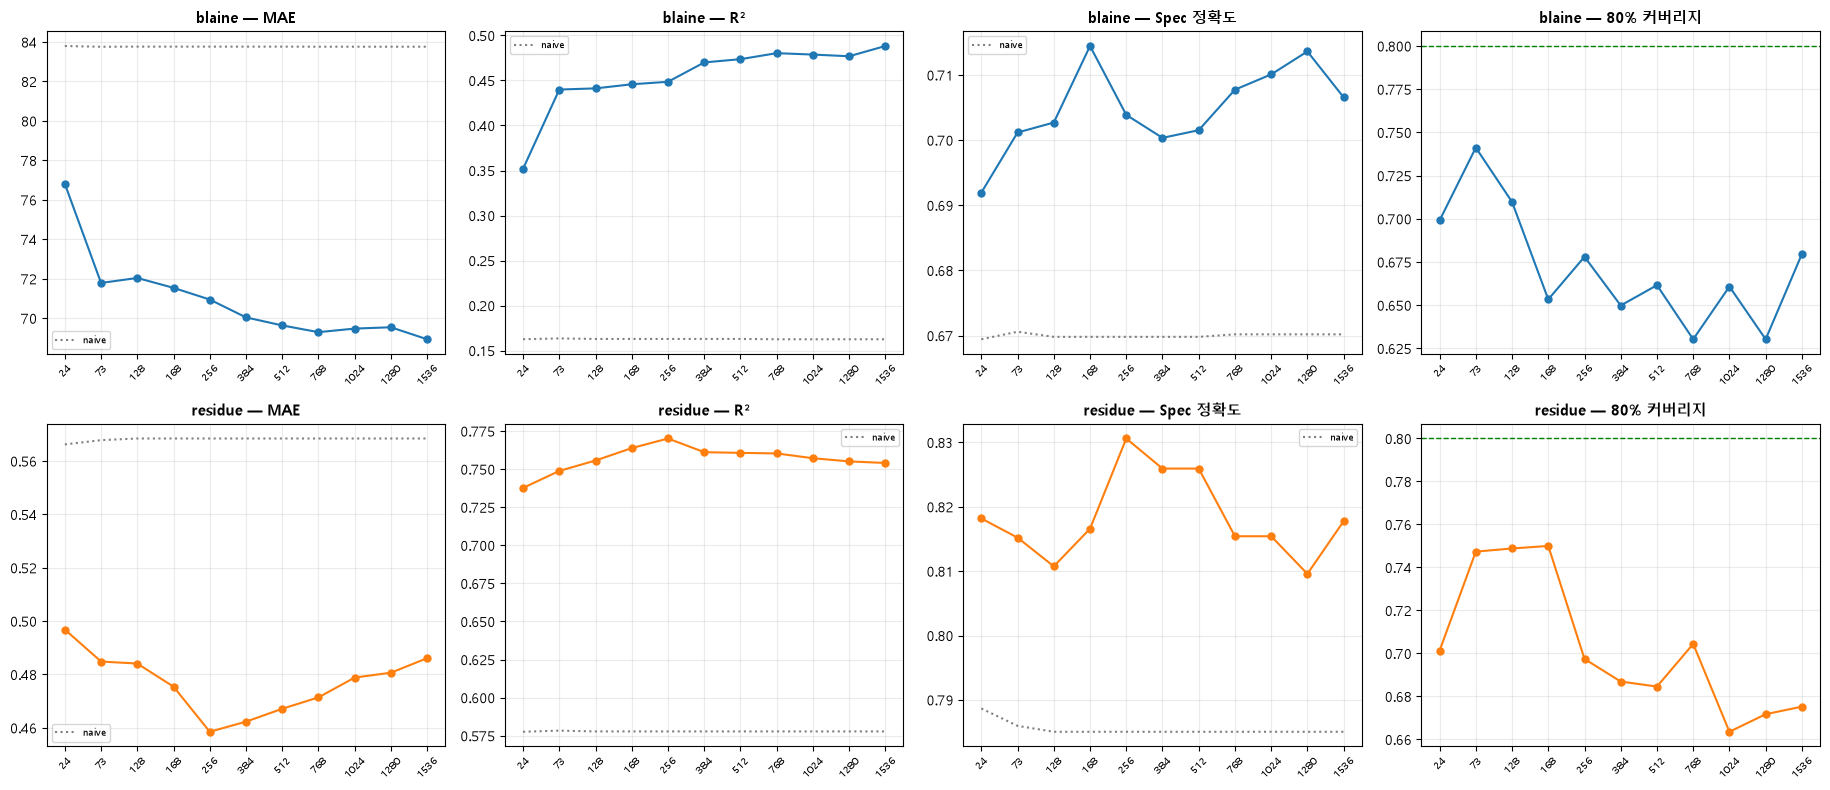

In [7]:
PM = ['MAE', 'R2', 'spec_accuracy', 'interval_coverage']
PL = {'MAE': 'MAE', 'R2': 'R²', 'spec_accuracy': 'Spec 정확도', 'interval_coverage': '80% 커버리지'}
xs = list(range(len(CONTEXTS)))
fig, axes = plt.subplots(len(TARGETS), len(PM), figsize=(4.6 * len(PM), 4.0 * len(TARGETS)))
for i, t in enumerate(TARGETS):
    mt = {ctx: compute_metrics(raw[t]['Full fine-tuning'][ctx], cfg.SPEC_RANGES[t]) for ctx in CONTEXTS}
    nv = {ctx: naive_metrics(t, ctx) for ctx in CONTEXTS}
    for j, k in enumerate(PM):
        ax = axes[i, j]
        ax.plot(xs, [mt[ctx][k] for ctx in CONTEXTS], marker='o', ms=5, color=COLOR[t])
        if k in ('MAE', 'R2', 'spec_accuracy'):
            ax.plot(xs, [nv[ctx][k] for ctx in CONTEXTS], ls=':', color='grey', label='naive')
            ax.legend(fontsize=7)
        if k == 'interval_coverage':
            ax.axhline(0.80, color='green', ls='--', lw=1)
        ax.set_xticks(xs); ax.set_xticklabels(CONTEXTS, rotation=45, fontsize=7)
        ax.set_title(f'{t} — {PL[k]}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


## 7. zero-shot / LoRA / Full fine-tuning 비교 (11 ctx 전부)

패널마다 세 방식을 겹쳐 그림 (행=target, 열=지표). MAE 낮을수록, R²·Spec 높을수록, 80% 커버리지는 초록선(0.80)에 가까울수록.

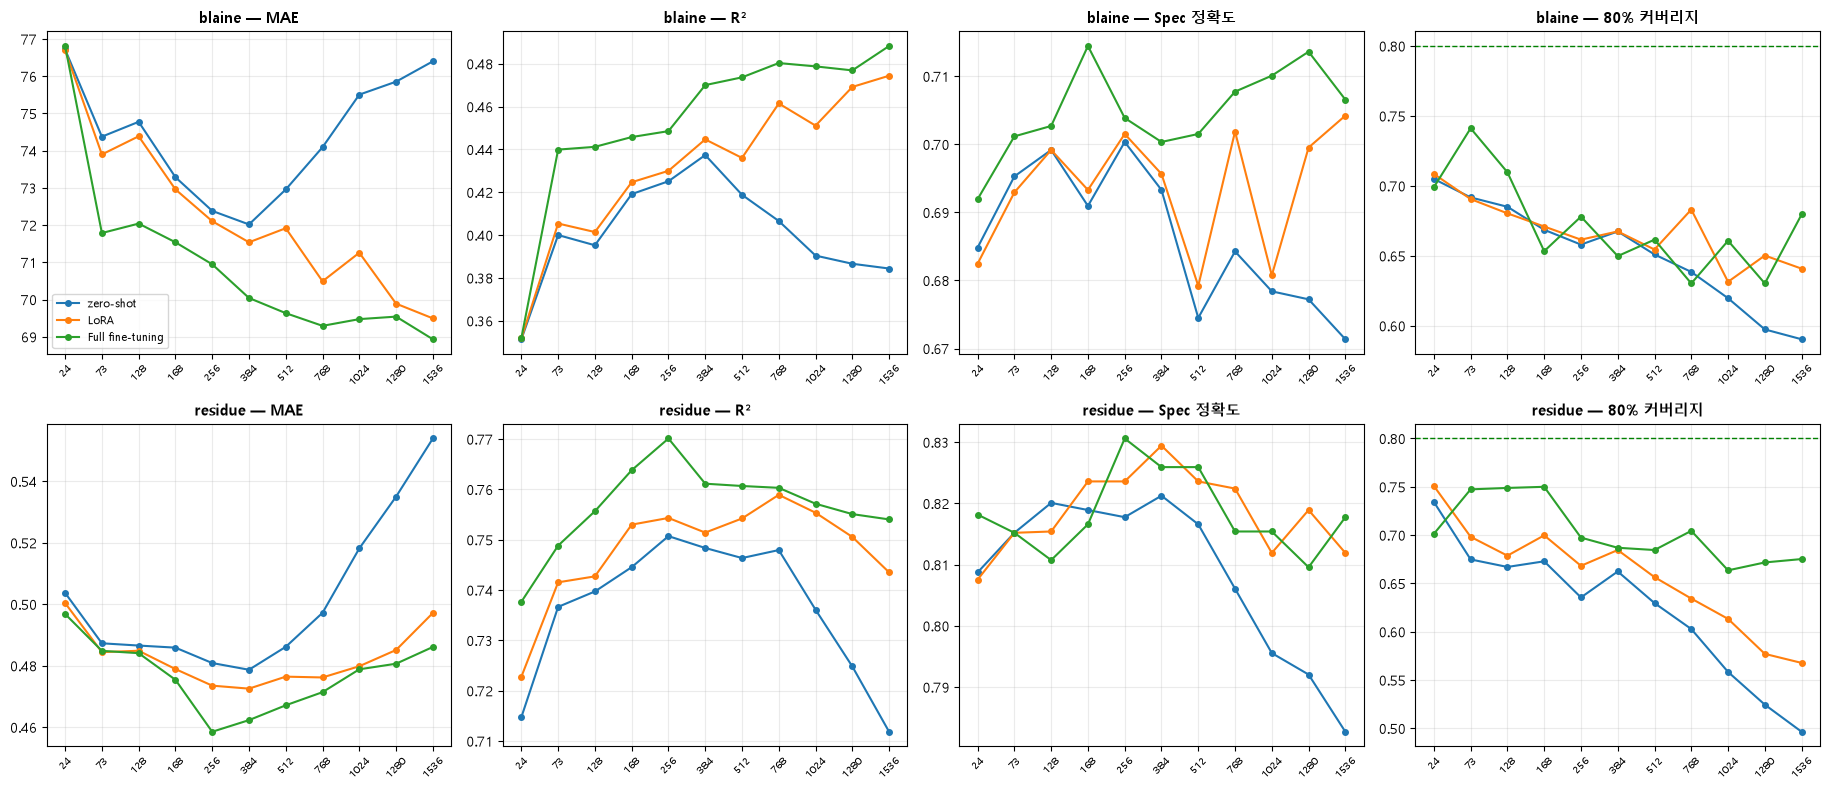

--- blaine · zero-shot ---
 ctx     MAE     R2  spec_acc  cov80  skill
  24 76.7189 0.3514    0.6848 0.7050 0.9148
  73 74.3765 0.4000    0.6953 0.6918 0.8873
 128 74.7752 0.3953    0.6992 0.6851 0.8919
 168 73.2873 0.4192    0.6910 0.6686 0.8753
 256 72.3826 0.4252    0.7004 0.6580 0.8654
 384 72.0184 0.4374    0.6933 0.6675 0.8619
 512 72.9584 0.4188    0.6745 0.6510 0.8726
 768 74.0933 0.4066    0.6843 0.6385 0.8860
1024 75.5057 0.3904    0.6784 0.6197 0.9025
1280 75.8543 0.3866    0.6772 0.5974 0.9070
1536 76.4006 0.3844    0.6714 0.5904 0.9139

--- blaine · LoRA ---
 ctx     MAE     R2  spec_acc  cov80  skill
  24 76.6942 0.3518    0.6825 0.7085 0.9144
  73 73.8985 0.4054    0.6929 0.6906 0.8818
 128 74.3867 0.4014    0.6992 0.6804 0.8874
 168 72.9598 0.4247    0.6933 0.6710 0.8714
 256 72.1059 0.4300    0.7015 0.6616 0.8621
 384 71.5388 0.4447    0.6957 0.6675 0.8560
 512 71.9170 0.4361    0.6792 0.6545 0.8599
 768 70.4908 0.4615    0.7019 0.6831 0.8427
1024 71.2586 0.4511    0.6

In [8]:
fig, axes = plt.subplots(len(TARGETS), len(PM), figsize=(4.6 * len(PM), 4.0 * len(TARGETS)))
for i, t in enumerate(TARGETS):
    for j, k in enumerate(PM):
        ax = axes[i, j]
        for label in METHODS:
            ys = [compute_metrics(raw[t][label][ctx], cfg.SPEC_RANGES[t])[k] for ctx in CONTEXTS]
            ax.plot(xs, ys, marker='o', ms=4, color=MCOLOR[label], label=label)
        if k == 'interval_coverage':
            ax.axhline(0.80, color='green', ls='--', lw=1)
        ax.set_xticks(xs); ax.set_xticklabels(CONTEXTS, rotation=45, fontsize=7)
        ax.set_title(f'{t} — {PL[k]}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.25)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for t in TARGETS:
    for label in METHODS:
        rows = []
        for ctx in CONTEXTS:
            m = compute_metrics(raw[t][label][ctx], cfg.SPEC_RANGES[t])
            rows.append({'ctx': ctx, 'MAE': round(m['MAE'], 4), 'R2': round(m['R2'], 4),
                         'spec_acc': round(m['spec_accuracy'], 4),
                         'cov80': round(m['interval_coverage'], 4),
                         'skill': round(normalized_skill_score(raw[t][label][ctx]), 4)})
        print(f'--- {t} · {label} ---')
        print(pd.DataFrame(rows).to_string(index=False)); print()


## 8. 결론

_아래는 build 스크립트에 하드코딩된 요약 — 숫자는 위 셀에서 다시 확인 가능._

- **blaine (Full)**: skill-score가 **ctx≈384부터 평탄** (384→1536: 0.838→0.824, 재학습   노이즈 수준). 최저는 ctx1536(0.824)이지만 384~1536 어디든 사실상 동급. **ctx24는 확실히   최악**(0.915 — naive와 큰 차이 없음).
- **residue (Full)**: **ctx256에서 최적**(skill 0.809, 매트릭스 전체 최고값). 그보다 길어지면   **단조적으로 악화** (256→1536: 0.809→0.857). ctx24도 나쁨(0.879). 즉 residue는 짧은~중간   context가 분명히 유리.
- **방식 비교**: 쓸모 있는 구간(ctx≥73)에서 **Full > LoRA > zero-shot**이 거의 모든 ctx에서   성립 (MAE·R²·Spec 전부). ctx24에서만 셋이 도토리 키재기. LoRA는 zero-shot보다 확실히 낫지만   Full엔 못 미침 → **Full fine-tuning 채택이 데이터로 뒷받침됨** (구 folder 결론과 동일).
- **80% 예측구간 커버리지**: 전 구간 49~75%로 목표(0.80) 미달. 다만 **짧은 ctx(73~168)에서   가장 높음**(residue Full 73~168에서 74~75%) — 긴 context일수록 예측구간이 좁아지며 과신.
- **구 folder 결론(blaine ctx1024 / residue ctx1536)과 반대.** 그건 비실측 시간대 값이 스며   있던 구 xlsx 기준이고, 긴 context가 그 carry-forward 규칙성을 주워 담던 것으로 보임. 실측치   데이터에서는 **residue는 ctx256, blaine은 ctx≈384+ 평탄**.
- **권장**: 한 값으로 통일하면 **ctx256** (residue 최적 + blaine 평탄 시작점 근처).   타깃별로 두면 blaine 384~768 / residue 256.

미해결(구 folder에서 이어짐): 80% 커버리지 과신, ctx24 극단 케이스 외 512 미만 미세 구조, 1536 이후 추가 스윕 필요성 없음(둘 다 이미 악화 추세).